# Polinomial Models

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Sample dataset
data = {
    'Study_Hours': [1, 2, 3, 4, 5, 6],
    'Exam_Score': [50, 65, 75, 80, 85, 88]
}

# Create a DataFrame from the dataset
df = pd.DataFrame(data)

In [3]:
# Extract the features (Study_Hours) and target (Exam_Score)
X = df[['Study_Hours']]
y = df['Exam_Score']

In [4]:
# Fit linear regression for comparison
linear_model = LinearRegression()
linear_model.fit(X, y)

# Fit polynomial regression
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

LinearRegression()

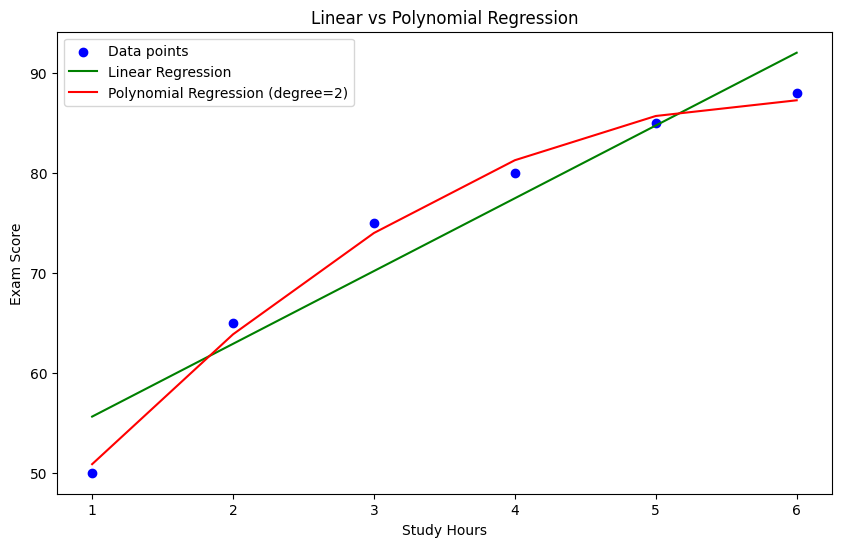

Linear Regression - MSE: 13.650793650793647 , R^2: 0.9189730302673419
Polynomial Regression - MSE: 0.9523809523809579 , R^2: 0.994346955600047


In [6]:
y_pred_linear = linear_model.predict(X)
y_pred_poly = poly_model.predict(X_poly)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred_linear, color='green', label='Linear Regression')
plt.plot(X, y_pred_poly, color='red', label='Polynomial Regression (degree=2)')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.show()

# Evaluate the models
mse_linear = mean_squared_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)
mse_poly = mean_squared_error(y, y_pred_poly)
r2_poly = r2_score(y, y_pred_poly)

print("Linear Regression - MSE:", mse_linear, ", R^2:", r2_linear)
print("Polynomial Regression - MSE:", mse_poly, ", R^2:", r2_poly)

# Exponential regression

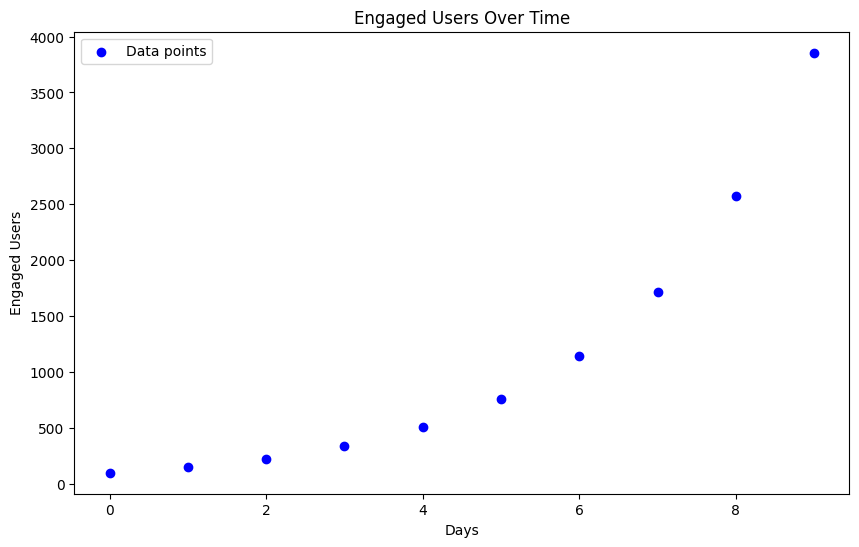

Linear Regression - MSE: 261371.25333333333 , R^2: 0.811021837748588
Exponential Regression - MSE: 0.051620979712970784 , R^2: 0.9999999626766993


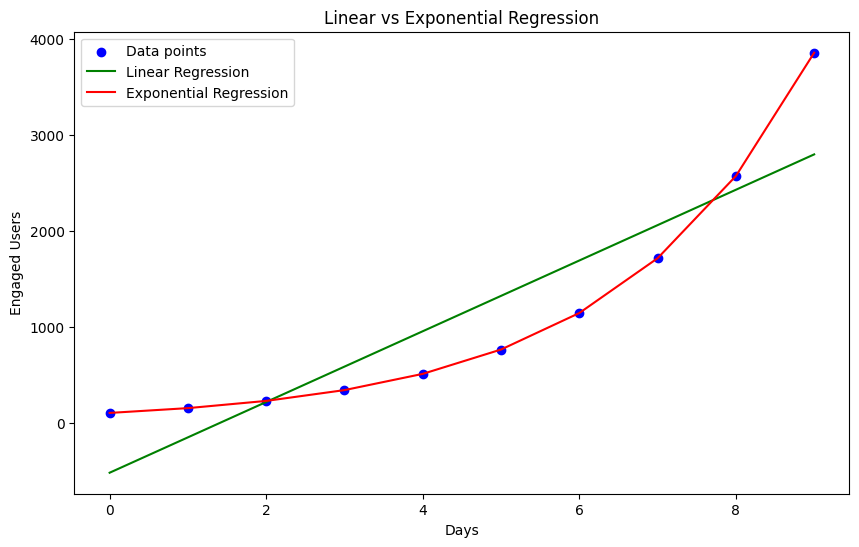

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit

# Sample dataset
data = {
    'Date': pd.date_range(start='2022-01-01', periods=10),
    'Engaged_Users': [100, 150, 225, 338, 507, 761, 1142, 1713, 2570, 3855]
}

# Create a DataFrame from the dataset
df = pd.DataFrame(data)
df['Days'] = (df['Date'] - df['Date'].min()).dt.days  # Convert dates to integer days

# Extract the features (Days) and target (Engaged_Users)
X = df[['Days']]
y = df['Engaged_Users']

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.xlabel('Days')
plt.ylabel('Engaged Users')
plt.title('Engaged Users Over Time')
plt.legend()
plt.show()

# Fit linear regression for comparison
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

# Define the exponential function for fitting
def exponential_func(x, a, b):
    return a * np.exp(b * x)

# Fit exponential regression
params, _ = curve_fit(exponential_func, X.squeeze(), y, p0=(1, 0.1))
y_pred_exp = exponential_func(X, *params)

# Evaluate the models
mse_linear = mean_squared_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)

mse_exp = mean_squared_error(y, y_pred_exp)
r2_exp = r2_score(y, y_pred_exp)

# Print evaluation metrics
print("Linear Regression - MSE:", mse_linear, ", R^2:", r2_linear)
print("Exponential Regression - MSE:", mse_exp, ", R^2:", r2_exp)

# Plot both models for comparison
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred_linear, color='green', label='Linear Regression')
plt.plot(X, y_pred_exp, color='red', label='Exponential Regression')
plt.xlabel('Days')
plt.ylabel('Engaged Users')
plt.title('Linear vs Exponential Regression')
plt.legend()
plt.show()


# Power models

Power Regression - MSE: 73.29284559421146 , R^2: 0.9997997770954759


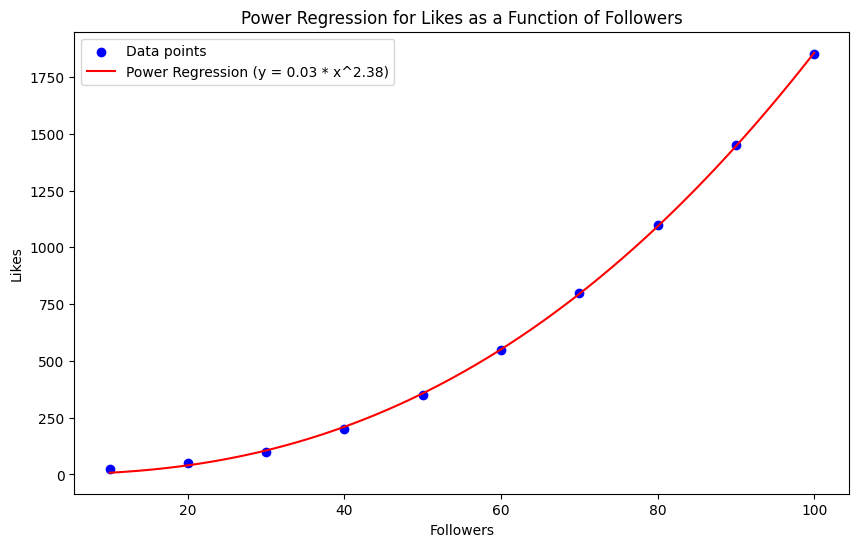

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Create a DataFrame with the sample data
data = {
    'User_ID': range(1, 11),
    'Followers': np.arange(10, 110, 10),
    'Likes': [25, 50, 100, 200, 350, 550, 800, 1100, 1450, 1850],
    'Shares': [5, 10, 20, 40, 70, 110, 160, 220, 290, 370],
    'Comments': [2, 4, 8, 16, 28, 44, 64, 88, 116, 148]
}
df = pd.DataFrame(data)

# Define the power function for regression
def power_func(x, a, b):
    return a * np.power(x, b)

# Perform power regression for Likes as a function of Followers
X = df['Followers']
y = df['Likes']
params, _ = curve_fit(power_func, X, y, p0=(1, 1))  # Initial guess a=1, b=1
a, b = params  # Extract fitted parameters

# Generate a range of Followers values for the fitted curve
X_fit = np.linspace(X.min(), X.max(), 100)
y_fit = power_func(X_fit, a, b)

# Calculate the predicted Likes using the fitted parameters
y_pred = power_func(X, a, b)

# Evaluate the model
mse_power = mean_squared_error(y, y_pred)
r2_power = r2_score(y, y_pred)

# Print evaluation metrics
print("Power Regression - MSE:", mse_power, ", R^2:", r2_power)

# Create a plot to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X_fit, y_fit, color='red', label=f'Power Regression (y = {a:.2f} * x^{b:.2f})')
plt.xlabel('Followers')
plt.ylabel('Likes')
plt.title('Power Regression for Likes as a Function of Followers')
plt.legend()
plt.show()
